# Assignment_8_Regularization

Apply regularization to avoid overfitting.


## Aim
Apply L1 and L2 regularization to reduce overfitting and compare the models.

Result folder: /content/results


,Model,MAE,MSE,R2
0,Linear Regression,42.794095,2900.193628,0.452603
1,Ridge Regression,42.811999,2892.014566,0.454147
2,Lasso Regression,42.805234,2884.624289,0.455541


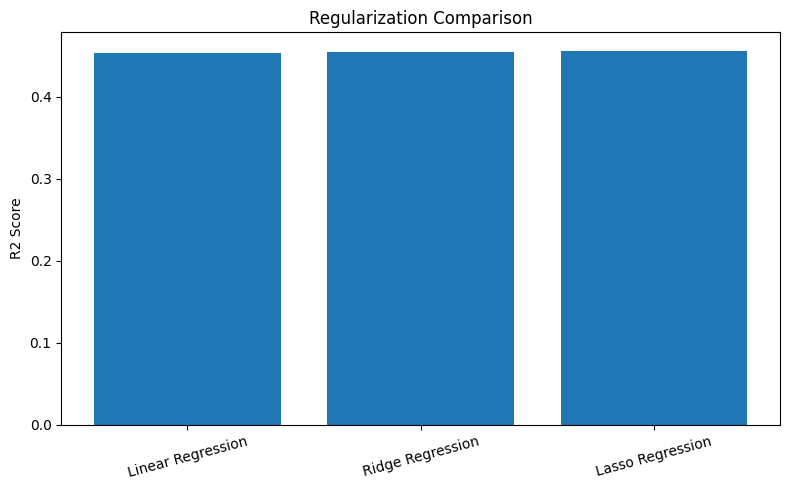

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULT_DIR = "/content/results"
os.makedirs(RESULT_DIR, exist_ok=True)

print("Result folder:", RESULT_DIR)

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

data=load_diabetes()
X_train,X_test,y_train,y_test=train_test_split(
    data.data,data.target,test_size=.2,random_state=42)

models={
    "Linear Regression":make_pipeline(StandardScaler(),LinearRegression()),
    "Ridge Regression":make_pipeline(StandardScaler(),Ridge(alpha=1.0)),
    "Lasso Regression":make_pipeline(StandardScaler(),Lasso(alpha=.1,max_iter=10000))
}

rows=[]
for name,model in models.items():
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    rows.append([name,
                 mean_absolute_error(y_test,pred),
                 mean_squared_error(y_test,pred),
                 r2_score(y_test,pred)])

results=pd.DataFrame(rows,columns=["Model","MAE","MSE","R2"])
display(results)
results.to_csv(f"{RESULT_DIR}/regularization_results.csv",index=False)

plt.figure(figsize=(8,5))
plt.bar(results["Model"],results["R2"])
plt.ylabel("R2 Score")
plt.title("Regularization Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/regularization_comparison.png",dpi=150)
plt.show()


In [ ]:
import shutil
from google.colab import files
shutil.make_archive("/content/Assignment_8_Results","zip",RESULT_DIR)
files.download("/content/Assignment_8_Results.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>